# Predicting Next-Week Stock-outs with Machine Learning

**Author:** Fordrane Albert Okumu · **Tools:** Python · scikit-learn · XGBoost · LightGBM · SHAP · Airtable API · Softr · LLM briefings

---

## 0. The business problem

An empty shelf is the most expensive event in FMCG retail. The shopper buys a competitor's product or nothing, the retailer loses margin, and the brand loses visibility. In my work on **MerchTrack**, real-time execution monitoring cut short-supply incidents to **zero**. This project shows the **predictive** version of that idea:

> *Every Sunday night, score every outlet × SKU and flag the ones likely to run out **next week**, so a merchandiser or the van-sales team can act **before** the shelf goes empty.*

### What this notebook covers

1. **Data & leakage-safe features:** what a planner knows on Sunday night
2. **Four ML models:** logistic regression (baseline), random forest, XGBoost, LightGBM
3. **Out-of-time evaluation:** train on older weeks, tune on the next 8, test on the final 10
4. **Hyper-parameter tuning** on the validation weeks
5. **Explainability with SHAP:** *why* is this shelf at risk?
6. **Cost-based alert threshold:** how many alerts are worth sending?
7. **From model to operations:** reason codes → **Airtable** → **Softr** field portal → **AI-written** manager briefing

### The data

The data is a **synthetic** weekly inventory panel: 220 outlets × 15 dairy/deli SKUs × 60 weeks (about 185k rows). It's simulated by [`data/generate_data.py`](../data/generate_data.py) with Poisson demand, seasonality, promotions, holidays, order-up-to replenishment with human error, depot shortages, late deliveries and merchandiser top-ups. Every stock-out has a cause the model can learn from. No real company data is used.

## 1. Setup

In [1]:
import sys, warnings, json
from pathlib import Path
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, precision_recall_curve, roc_curve
from sklearn.calibration import calibration_curve
import xgboost as xgb, lightgbm as lgb, shap

ROOT = Path.cwd().parent if Path.cwd().name == "python" else Path.cwd()
sys.path.insert(0, str(ROOT / "python"))
from features import load, time_split, NUMERIC, CATEGORICAL
OUT = ROOT / "outputs"; OUT.mkdir(exist_ok=True)
TEAL, AMBER, GREY, RED, BLUE = "#0f766e", "#b45309", "#94a3b8", "#b91c1c", "#2563eb"
COL = {"Logistic regression": GREY, "Random forest": BLUE, "XGBoost": AMBER, "LightGBM": TEAL}
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titleweight": "bold", "font.size": 10})

## 2. Load the data and build features

Each row is **one outlet × SKU at the end of one week**. The features capture three things.

| Group | Features | Why they matter |
|---|---|---|
| **Stock position** | `closing_stock`, `avg_sales_4w`, `weeks_of_cover` (= stock ÷ recent weekly sales), `sales_trend` | Low cover against strong recent sales is the most direct path to an empty shelf |
| **Supply reliability** | `weeks_since_delivery`, `late_deliveries_8w`, `short_deliveries_8w`, `depot_shortage_this_week`, `distance_km` | Late or short deliveries cause most real-world stock-outs |
| **Next week's plan** (known in advance) | `delivery_next_week`, `promo_next_week`, `holiday_next_week` | A promotion with no delivery scheduled is a classic stock-out recipe |
| **Context** | `stockouts_8w`, `merch_visits_per_week`, `channel`, `region`, `category`, `shelf_life_days`, `price_kes` | Chronic problem outlets, merchandiser coverage, product type |

**Label:** `target = 1` if the outlet-SKU stocks out **in the following week**. Only information available on Sunday night is used, so there's **no leakage**.

In [2]:
d = load()
print(f"{len(d):,} outlet-SKU-weeks | {d.outlet_id.nunique()} outlets | {d.sku.nunique()} SKUs | "
      f"next-week stock-out rate: {d.target.mean():.1%}")
d[["week", "outlet_id", "sku", "channel", "closing_stock", "avg_sales_4w", "weeks_of_cover",
   "delivery_next_week", "promo_next_week", "late_deliveries_8w", "target"]].head(6).round(2)

157,641 outlet-SKU-weeks | 220 outlets | 15 SKUs | next-week stock-out rate: 8.5%


,week,outlet_id,sku,channel,closing_stock,avg_sales_4w,weeks_of_cover,delivery_next_week,promo_next_week,late_deliveries_8w,target
8,2025-09-01,OUT0001,Bacon 250g,Supermarket,16,23.50,0.68,1,0,1.0,0
9,2025-09-08,OUT0001,Bacon 250g,Supermarket,25,22.25,1.12,1,0,0.0,0
10,2025-09-15,OUT0001,Bacon 250g,Supermarket,20,22.25,0.90,1,0,0.0,0
11,2025-09-22,OUT0001,Bacon 250g,Supermarket,26,20.75,1.25,1,0,0.0,0
12,2025-09-29,OUT0001,Bacon 250g,Supermarket,12,21.25,0.56,1,0,0.0,0
13,2025-10-06,OUT0001,Bacon 250g,Supermarket,22,19.75,1.11,1,0,0.0,0


**Interpretation:** about **1 in 12** outlet-SKU-weeks ends in a stock-out the following week. That's an **imbalanced** problem: a model that always says "no stock-out" would be about 91% accurate and useless. We therefore judge models on **PR-AUC** (precision-recall) and on **how many real stock-outs the top alerts catch**, not on accuracy.

## 3. What drives stock-outs? (exploratory view)

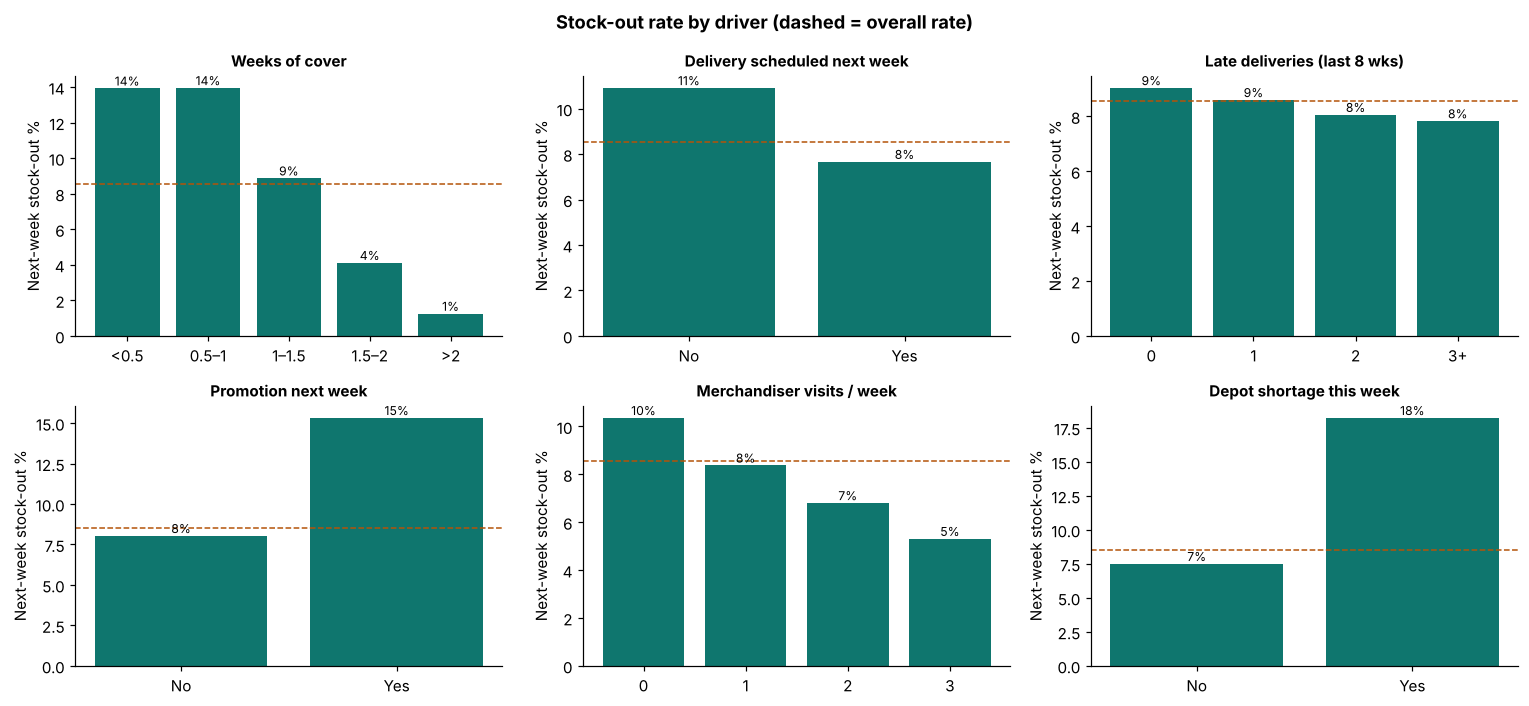

In [3]:
def rate(col, bins=None, labels=None):
    g = pd.cut(d[col], bins, labels=labels) if bins is not None else d[col]
    return d.groupby(g, observed=True).target.mean()
panels = {
    "Weeks of cover": rate("weeks_of_cover", [-.1, .5, 1, 1.5, 2, 99], ["<0.5", "0.5–1", "1–1.5", "1.5–2", ">2"]),
    "Delivery scheduled next week": rate("delivery_next_week").rename({0: "No", 1: "Yes"}),
    "Late deliveries (last 8 wks)": rate("late_deliveries_8w", [-1, 0, 1, 2, 99], ["0", "1", "2", "3+"]),
    "Promotion next week": rate("promo_next_week").rename({0: "No", 1: "Yes"}),
    "Merchandiser visits / week": rate("merch_visits_per_week"),
    "Depot shortage this week": rate("depot_shortage_this_week").rename({0: "No", 1: "Yes"}),
}
fig, axes = plt.subplots(2, 3, figsize=(14, 6.5))
for ax, (t, s) in zip(axes.flat, panels.items()):
    ax.bar(s.index.astype(str), s.values * 100, color=TEAL); ax.axhline(d.target.mean() * 100, ls="--", color=AMBER, lw=1)
    ax.set_title(t, fontsize=10); ax.set_ylabel("Next-week stock-out %")
    for i, v in enumerate(s.values): ax.text(i, v * 100, f"{v:.0%}", ha="center", va="bottom", fontsize=8)
fig.suptitle("Stock-out rate by driver (dashed = overall rate)", fontweight="bold")
fig.tight_layout(); fig.savefig(OUT / "01_drivers.png", dpi=150); plt.show()

**Interpretation:**

* **Weeks of cover** is the biggest single signal. Shelves with under one week of stock stock out about **14%** of the time, against about **1%** for shelves with more than two weeks.
* **Depot shortages** (about 18% vs 7%) and a **promotion next week** (about 15% vs 8%) roughly double the risk.
* **No delivery scheduled next week** raises risk (about 11% vs 8%). This is the *fortnightly delivery gap* that small outlets fall into.
* **Merchandiser coverage** lowers risk steadily, from about 10% with no visits to about 5% with three visits a week, because merchandisers spot low shelves and trigger top-ups.
* **Surprise: past late deliveries barely matter** (about 9% → 8%). A delivery that was late *this* week arrives *next* week, which boosts next week's stock. The chronic lateness of far-away outlets is already captured by distance from the depot. An intuitive feature is not always a predictive one, which is why we test rather than assume.

The drivers **interact**. Low cover is only dangerous if no delivery is coming, and a promotion only matters if stock is tight. Interactions like these are exactly what tree-based ML models capture and linear models miss.

## 4. Out-of-time split

With time-ordered data a **random** split would leak the future into training. We split **by week**:

| Set | Weeks | Purpose |
|---|---|---|
| **Train** | oldest 33 weeks | Fit models |
| **Validation** | next 8 weeks | Tune hyper-parameters, choose the alert threshold |
| **Test** | final 10 weeks | One final, untouched evaluation, as if the model were already live |

In [4]:
tr, va, te = time_split(d)
for name, s in [("Train", tr), ("Validation", va), ("Test", te)]:
    print(f"{name:<11} {s.week.min():%d %b %Y} – {s.week.max():%d %b %Y} | {len(s):>7,} rows | stock-out rate {s.target.mean():.1%}")
def X(df, cols=None):
    m = pd.get_dummies(df[NUMERIC + CATEGORICAL], columns=CATEGORICAL, dtype=float)
    return m if cols is None else m.reindex(columns=cols, fill_value=0)
Xtr = X(tr); cols = Xtr.columns; Xva, Xte = X(va, cols), X(te, cols)
ytr, yva, yte = tr.target.values, va.target.values, te.target.values

Train       01 Sep 2025 – 13 Apr 2026 | 102,003 rows | stock-out rate 8.3%
Validation  20 Apr 2026 – 08 Jun 2026 |  24,728 rows | stock-out rate 7.2%
Test        15 Jun 2026 – 17 Aug 2026 |  30,910 rows | stock-out rate 10.5%


## 5. Four models

| Model | How it works | Why include it |
|---|---|---|
| **Logistic regression** | Linear model of the log-odds; features standardised | Transparent baseline. Shows how much the non-linear models add |
| **Random forest** | Averages hundreds of deep decision trees grown on bootstrap samples | Robust, handles interactions, little tuning needed |
| **XGBoost** | Gradient-boosted trees: each new tree corrects the errors of the previous ones, with regularisation | Industry standard for tabular data |
| **LightGBM** | Gradient boosting with leaf-wise growth and histogram binning | Very fast on large data; often the most accurate |

### Hyper-parameter tuning

For the two boosting models we try a small random search of settings (number of trees, learning rate, tree depth/leaves, subsampling). Each setting is **trained on train** and **scored on validation PR-AUC**. The test set is never touched during tuning.

In [5]:
rng = np.random.default_rng(0)
def tune(make, space, n=10):
    best, rows = None, []
    for _ in range(n):
        params = {k: (v[rng.integers(len(v))]) for k, v in space.items()}
        m = make(**params).fit(Xtr, ytr)
        score = average_precision_score(yva, m.predict_proba(Xva)[:, 1])
        rows.append({**params, "valid PR-AUC": round(score, 4)})
        if best is None or score > best[0]: best = (score, params)
    return best[1], pd.DataFrame(rows).sort_values("valid PR-AUC", ascending=False)

xgb_space = {"n_estimators": [200, 400, 600], "learning_rate": [.03, .05, .1], "max_depth": [3, 4, 5, 6],
             "subsample": [.7, .8, 1.0], "colsample_bytree": [.6, .8, 1.0], "min_child_weight": [1, 5, 10]}
lgb_space = {"n_estimators": [200, 400, 600], "learning_rate": [.03, .05, .1], "num_leaves": [15, 31, 63],
             "min_child_samples": [20, 50, 100], "subsample": [.7, .8, 1.0], "colsample_bytree": [.6, .8, 1.0]}
best_xgb, xgb_grid = tune(lambda **p: xgb.XGBClassifier(**p, n_jobs=-1, random_state=0, eval_metric="logloss"), xgb_space)
best_lgb, lgb_grid = tune(lambda **p: lgb.LGBMClassifier(**p, subsample_freq=1, random_state=0, verbose=-1), lgb_space)
print("Best XGBoost:", best_xgb); print("Best LightGBM:", best_lgb)
xgb_grid.head(5)

Best XGBoost: {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 6, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 10}
Best LightGBM: {'n_estimators': 200, 'learning_rate': 0.03, 'num_leaves': 63, 'min_child_samples': 100, 'subsample': 0.7, 'colsample_bytree': 0.6}


,n_estimators,learning_rate,max_depth,subsample,colsample_bytree,min_child_weight,valid PR-AUC
8,200,0.05,6,0.8,0.8,10,0.3277
2,400,0.05,6,1.0,0.8,5,0.3245
0,600,0.05,5,0.7,0.6,1,0.3230
3,400,0.10,4,1.0,1.0,1,0.3215
4,400,0.10,5,0.7,1.0,10,0.3178


**Interpretation:** the spread of validation PR-AUC across settings shows how sensitive each model is to its hyper-parameters. Moderate depth and learning rate with some subsampling usually work best on noisy operational data, because shallower trees generalise better to new weeks.

### Final fit and test evaluation

Each model is refitted on **train + validation** with its chosen settings, then scored **once** on the 10 test weeks.

In [6]:
Xtv = pd.concat([Xtr, Xva]); ytv = np.r_[ytr, yva]
mu, sd = Xtv.mean(), Xtv.std().replace(0, 1)
models = {
    "Logistic regression": LogisticRegression(max_iter=3000),
    "Random forest": RandomForestClassifier(n_estimators=400, min_samples_leaf=20, n_jobs=-1, random_state=0),
    "XGBoost": xgb.XGBClassifier(**best_xgb, n_jobs=-1, random_state=0, eval_metric="logloss"),
    "LightGBM": lgb.LGBMClassifier(**best_lgb, subsample_freq=1, random_state=0, verbose=-1),
}
proba = {}
for name, m in models.items():
    if name == "Logistic regression":
        m.fit((Xtv - mu) / sd, ytv); proba[name] = m.predict_proba((Xte - mu) / sd)[:, 1]
    else:
        m.fit(Xtv, ytv); proba[name] = m.predict_proba(Xte)[:, 1]

def capture_at(p, y, share=.10):
    k = int(len(p) * share); top = np.argsort(-p)[:k]
    return y[top].sum() / y.sum(), y[top].mean()
rows = []
for name, p in proba.items():
    cap10, prec10 = capture_at(p, yte)
    rows.append({"model": name, "ROC-AUC": roc_auc_score(yte, p), "PR-AUC": average_precision_score(yte, p),
                 "Brier": brier_score_loss(yte, p), "stock-outs caught in top 10% alerts": cap10,
                 "precision of top 10%": prec10})
metrics = pd.DataFrame(rows).set_index("model").sort_values("PR-AUC", ascending=False)
metrics.loc["(no model: base rate)"] = [.5, yte.mean(), brier_score_loss(yte, np.full(len(yte), ytv.mean())), .10, yte.mean()]
metrics.to_csv(OUT / "test_metrics.csv"); metrics.round(3)

,ROC-AUC,PR-AUC,Brier,stock-outs caught in top 10% alerts,precision of top 10%
model,,,,,
XGBoost,0.832,0.478,0.073,0.420,0.441
LightGBM,0.832,0.478,0.073,0.418,0.439
Random forest,0.822,0.459,0.076,0.408,0.429
Logistic regression,0.780,0.367,0.081,0.367,0.386
(no model: base rate),0.500,0.105,0.095,0.100,0.105


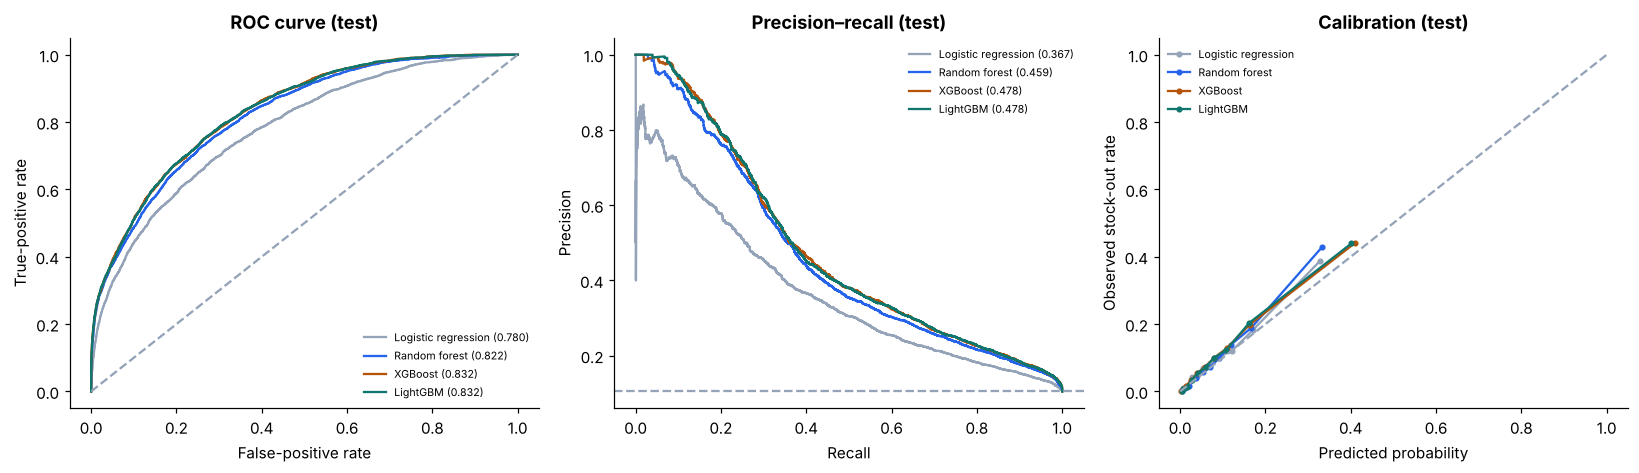

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
for name, p in proba.items():
    fpr, tpr, _ = roc_curve(yte, p); ax[0].plot(fpr, tpr, color=COL[name], label=f"{name} ({roc_auc_score(yte, p):.3f})")
    pr, rc, _ = precision_recall_curve(yte, p); ax[1].plot(rc, pr, color=COL[name], label=f"{name} ({average_precision_score(yte, p):.3f})")
    fr, mp = calibration_curve(yte, p, n_bins=10, strategy="quantile"); ax[2].plot(mp, fr, "o-", color=COL[name], ms=3, label=name)
ax[0].plot([0, 1], [0, 1], ls="--", color=GREY); ax[0].set(title="ROC curve (test)", xlabel="False-positive rate", ylabel="True-positive rate")
ax[1].axhline(yte.mean(), ls="--", color=GREY); ax[1].set(title="Precision–recall (test)", xlabel="Recall", ylabel="Precision")
ax[2].plot([0, 1], [0, 1], ls="--", color=GREY); ax[2].set(title="Calibration (test)", xlabel="Predicted probability", ylabel="Observed stock-out rate")
for a in ax: a.legend(frameon=False, fontsize=7)
fig.tight_layout(); fig.savefig(OUT / "02_model_evaluation.png", dpi=150); plt.show()

**Interpretation:**

* All four models are far better than chance, but the **tree-based models clearly beat logistic regression**. The gap comes from **interactions** (low cover × no delivery × promotion) that a linear model can't represent without hand-built interaction terms.
* **XGBoost and LightGBM** are the strongest and essentially tied (ROC-AUC 0.83, PR-AUC 0.48), with the random forest close behind (0.46) and logistic regression well back (0.37). A PR-AUC of 0.48 against a base rate of 0.105 is the meaningful comparison for a rare event.
* In operational terms: alerting only the **top 10% riskiest** outlet-SKUs catches about **42%** of next week's stock-outs, at about **44% precision**, roughly four times better than random checks (10.5%).
* **Calibration:** predicted probabilities track observed rates closely across most of the range. The riskiest bin is slightly *under*-predicted, because the test weeks had a higher stock-out rate (10.5%) than training (8.3%). In production you'd recalibrate on recent weeks. Good calibration matters because section 7 uses the probabilities directly in money terms.

## 6. Explainability — *why* is this shelf at risk? (SHAP)

A merchandiser won't act on a black-box score. **SHAP** (SHapley Additive exPlanations) splits each prediction into contributions from each feature, so the score can be explained as *"risk is high because cover is only 0.4 weeks, no delivery is scheduled and a promotion starts."*

* The **summary plot** shows which features matter most across all predictions, and in which direction.
* **Reason codes** for each alert come from that alert's top positive SHAP contributions.

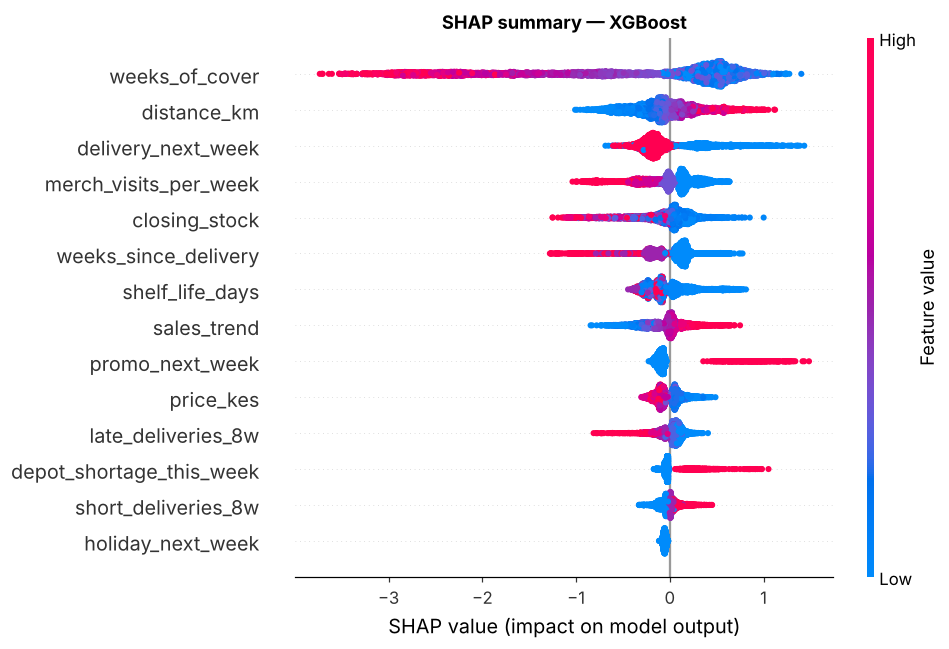

,mean |SHAP|
weeks_of_cover,0.9952
distance_km,0.2603
delivery_next_week,0.2581
merch_visits_per_week,0.2258
closing_stock,0.2078
weeks_since_delivery,0.1917
shelf_life_days,0.1788
sales_trend,0.1613
promo_next_week,0.1568
price_kes,0.1053


In [8]:
best_name = metrics.drop("(no model: base rate)")["PR-AUC"].idxmax()
best = models[best_name]
sample = Xte.sample(4000, random_state=0)
explainer = shap.TreeExplainer(best)
sv = explainer.shap_values(sample)
sv = sv[1] if isinstance(sv, list) else sv
plt.figure()
shap.summary_plot(sv, sample, max_display=14, show=False, plot_size=(9, 6))
plt.title(f"SHAP summary — {best_name}", fontweight="bold"); plt.tight_layout()
plt.savefig(OUT / "03_shap_summary.png", dpi=150, bbox_inches="tight"); plt.show()
imp = pd.Series(np.abs(sv).mean(0), index=sample.columns).sort_values(ascending=False)
imp.head(10).round(4).to_frame("mean |SHAP|")

**How to read the SHAP plot:** each dot is one outlet-SKU-week. Its horizontal position is how much that feature pushed the stock-out risk up (right) or down (left). Colour shows the feature's value (red = high, blue = low).

* **Weeks of cover:** blue dots (low cover) sit far to the right, so low cover strongly raises risk.
* **Delivery next week:** low values (no delivery coming) push risk up, and a scheduled delivery pulls it down.
* **Distance from the depot** is the second most important feature. Far-away outlets get more late deliveries, so it acts as a proxy for supply reliability.
* **Merchandiser visits** are protective: frequent visits mean low shelves get topped up.
* A **promotion next week**, a **depot shortage**, repeated **short deliveries** and **accelerating sales** push risk up.
* Some effects are less obvious. A delivery *this* week (weeks since delivery = 0) slightly *raises* next week's risk for fortnightly outlets, because the next truck is two weeks away. The model learns the delivery rhythm, not just the stock level.

The model has learned the operational logic of the supply chain, which is why its alerts can be **explained and trusted**.

## 7. How many alerts should we send? Expected value under team capacity

Not every stock-out costs the same. An empty shelf of fast-selling fresh milk in a supermarket loses far more than a slow SKU in a small duka. So instead of a single probability cut-off, each outlet-SKU gets an **expected value of alerting**:

```
expected value = P(stock-out) × save rate × lost margin  −  cost of acting on the alert
lost margin    = one week of sales × price × 30% gross margin
```

**Assumptions** (illustrative; replace with real figures): acting on an alert (an in-app task for the merchandiser, or a telesales call) costs **KES 50**, and an alert acted on **prevents 60%** of the stock-outs it flags. This only works because the model's probabilities are **well calibrated** (section 5).

The field team can only handle so many alerts a week, so we rank alerts by expected value and ask: *for a given weekly capacity, how many stock-outs, and how much margin, does the list protect?*

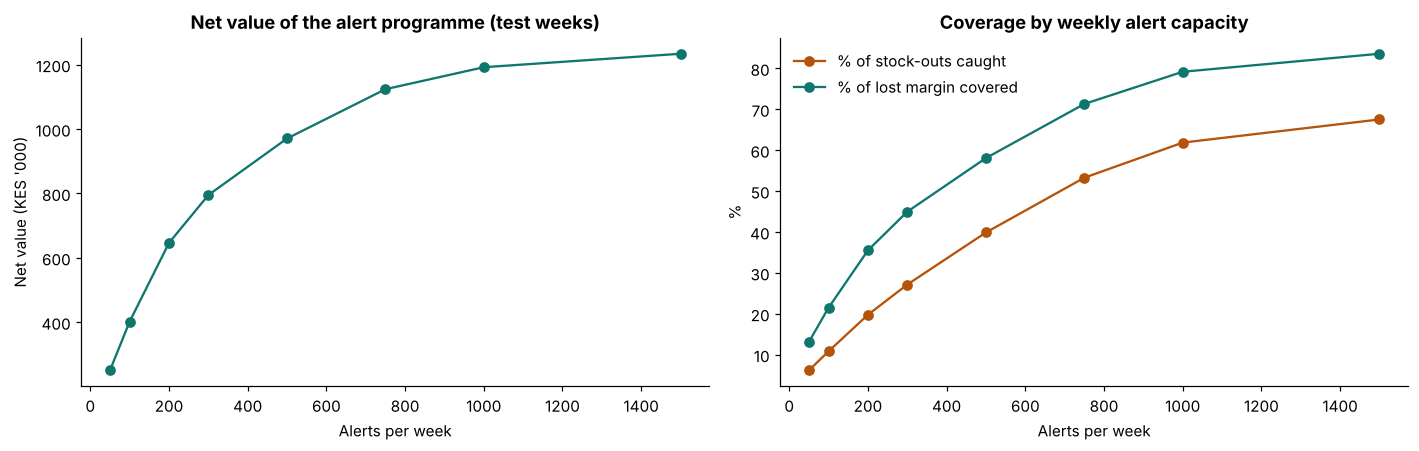

For comparison, 300 RANDOM checks a week would be worth about KES 54k over the same 10 weeks.


,alerts sent,stock-outs caught,% of stock-outs caught,precision,% of lost margin covered,net value KES (10 wks)
alerts per week (capacity),,,,,,
50,500,200,0.062,0.400,0.131,250431.275
100,1000,352,0.108,0.352,0.215,401857.150
200,2000,642,0.198,0.321,0.355,646413.425
300,3000,882,0.271,0.294,0.450,795067.500
500,5000,1296,0.399,0.259,0.581,970851.350
750,7500,1731,0.533,0.231,0.713,1123920.075
1000,9442,2010,0.618,0.213,0.792,1192270.900
1500,10457,2194,0.675,0.210,0.836,1234087.025


In [9]:
COST, SAVE, MARGIN = 50, .60, .30
t = te.copy(); t["p"] = proba[best_name]
t["loss"] = t.avg_sales_4w * t.price_kes * MARGIN
t["ev"] = t.p * SAVE * t.loss - COST
total_loss = (t.target * t.loss).sum()
rows = []
for cap in [50, 100, 200, 300, 500, 750, 1000, 1500]:
    s = t.sort_values("ev", ascending=False).groupby("week").head(cap); s = s[s.ev > 0]
    rows.append({"alerts per week (capacity)": cap, "alerts sent": len(s), "stock-outs caught": int(s.target.sum()),
                 "% of stock-outs caught": s.target.sum() / t.target.sum(), "precision": s.target.mean(),
                 "% of lost margin covered": (s.target * s.loss).sum() / total_loss,
                 "net value KES (10 wks)": (s.target * SAVE * s.loss).sum() - len(s) * COST})
cap_tab = pd.DataFrame(rows).set_index("alerts per week (capacity)")
random_net = SAVE * total_loss * (300 * t.week.nunique() / len(t)) - 300 * t.week.nunique() * COST
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ax[0].plot(cap_tab.index, cap_tab["net value KES (10 wks)"] / 1e3, "o-", color=TEAL)
ax[0].set(title="Net value of the alert programme (test weeks)", xlabel="Alerts per week", ylabel="Net value (KES '000)")
ax[1].plot(cap_tab.index, cap_tab["% of stock-outs caught"] * 100, "o-", color=AMBER, label="% of stock-outs caught")
ax[1].plot(cap_tab.index, cap_tab["% of lost margin covered"] * 100, "o-", color=TEAL, label="% of lost margin covered")
ax[1].set(title="Coverage by weekly alert capacity", xlabel="Alerts per week", ylabel="%"); ax[1].legend(frameon=False)
fig.tight_layout(); fig.savefig(OUT / "04_alert_capacity.png", dpi=150); plt.show()
cap_tab.to_csv(OUT / "alert_capacity.csv")
print(f"For comparison, 300 RANDOM checks a week would be worth about KES {random_net/1e3:,.0f}k over the same 10 weeks.")
cap_tab.round(3)

**Interpretation:**

* With a capacity of **300 alerts a week** (about 10% of outlet-SKUs), the value-ranked list catches about **27% of all stock-outs** but covers about **45% of the lost margin**. Ranking by *value* rather than by probability sends the team to the shelves that matter most.
* Net value keeps rising with capacity in this simulation: an alert costs little compared with the margin of a fast-moving SKU. The real constraint is **team time**. Picking the capacity is a management decision, and this table is the evidence for it.
* The same number of **random** checks (300 a week) would be worth only about **KES 54k**, against about **KES 795k** for the model-ranked list, roughly **15× less**. The model is what makes a proactive programme pay.

## 8. From model to action — alerts, Airtable, Softr and an AI briefing

A model only creates value when its output reaches the person who can act. The production design:

```
Sunday night: score all outlet-SKUs  ──►  alerts + SHAP reason codes  ──►  Airtable "Stock-out Alerts" table
                                                                              │
             Softr field portal (merchandisers see their outlets' alerts, mark "actioned") ◄─┘
                                                                              │
             AI briefing: an LLM turns the alert table into a short plain-English summary for each regional manager
```

Below we generate this week's alert list with **reason codes**. The scripts in [`integrations/`](../integrations) then push it to Airtable, describe the Softr portal, and write the AI briefing.

In [10]:
latest = te[te.week == te.week.max()].copy()
X_latest = X(latest, cols)
latest["risk"] = best.predict_proba(X_latest)[:, 1]
latest["ev"] = latest.risk * SAVE * latest.avg_sales_4w * latest.price_kes * MARGIN - COST
CAPACITY = 300
alerts = latest[latest.ev > 0].sort_values("ev", ascending=False).head(CAPACITY).sort_values("risk", ascending=False).copy()
sv_alerts = explainer.shap_values(X(alerts, cols)); sv_alerts = sv_alerts[1] if isinstance(sv_alerts, list) else sv_alerts

LABELS = {"weeks_of_cover": "low weeks of cover", "delivery_next_week": "no delivery scheduled next week",
          "promo_next_week": "promotion next week", "holiday_next_week": "holiday demand next week",
          "short_deliveries_8w": "repeated short deliveries",
          "depot_shortage_this_week": "depot shortage", "stockouts_8w": "recent stock-out history",
          "merch_visits_per_week": "low merchandiser coverage", "weeks_since_delivery": "no delivery scheduled next week",
          "closing_stock": "low closing stock", "avg_sales_4w": "strong recent sales", "sales_trend": "sales accelerating",
          "distance_km": "far from depot"}
# labels only describe the risky direction; a positive SHAP value means "this pushed risk up"
def reasons(row_sv):
    top = [cols[i] for i in np.argsort(-row_sv)[:5] if row_sv[i] > 0]
    out = [LABELS[c] for c in top if c in LABELS]
    return "; ".join(dict.fromkeys(out)) or "combination of factors"
alerts["reasons"] = [reasons(r) for r in sv_alerts]
alerts["suggested_action"] = np.where(alerts.delivery_next_week == 0, "Raise an emergency top-up order",
                              np.where(alerts.promo_next_week == 1, "Increase next delivery for the promotion",
                                       "Merchandiser check & reorder"))
alert_cols = ["week", "outlet_id", "channel", "region", "sku", "closing_stock", "weeks_of_cover", "risk", "ev", "reasons", "suggested_action"]
alerts[alert_cols].round(3).to_csv(OUT / "alerts_latest_week.csv", index=False)
print(f"Week of {latest.week.max():%d %b %Y}: {len(alerts)} alerts out of {len(latest):,} outlet-SKUs (capacity {CAPACITY}) | "
      f"stock-outs next week among alerted: {alerts.target.mean():.0%} vs {latest.target.mean():.0%} overall")
alerts[alert_cols].head(8).round(2)

Week of 17 Aug 2026: 300 alerts out of 3,091 outlet-SKUs (capacity 300) | stock-outs next week among alerted: 26% vs 8% overall


,week,outlet_id,channel,region,sku,closing_stock,weeks_of_cover,risk,ev,reasons,suggested_action
81478,2026-08-17,OUT0097,Petrol Station,Nairobi,Fresh Milk 500ml,0,0.00,0.88,215.83,no delivery scheduled next week; low weeks of ...,Raise an emergency top-up order
105778,2026-08-17,OUT0125,Duka,Coast,Yoghurt 250ml Kids,2,0.13,0.88,164.02,no delivery scheduled next week; low weeks of ...,Raise an emergency top-up order
67918,2026-08-17,OUT0080,Duka,Central,Yoghurt 500ml Strawberry,5,0.42,0.85,279.19,low weeks of cover; no delivery scheduled next...,Raise an emergency top-up order
120358,2026-08-17,OUT0142,Duka,Central,Yoghurt 500ml Vanilla,11,0.58,0.82,457.81,no delivery scheduled next week; low weeks of ...,Raise an emergency top-up order
121318,2026-08-17,OUT0144,Petrol Station,Nyanza,Bacon 250g,1,0.44,0.79,102.79,no delivery scheduled next week; low weeks of ...,Raise an emergency top-up order
8938,2026-08-17,OUT0011,Duka,Nyanza,Fresh Milk 500ml,26,0.83,0.78,235.95,no delivery scheduled next week; low weeks of ...,Raise an emergency top-up order
146218,2026-08-17,OUT0174,Petrol Station,Western,Burger Buns 6pk,9,1.44,0.77,104.95,promotion next week; no delivery scheduled nex...,Raise an emergency top-up order
157438,2026-08-17,OUT0187,Petrol Station,Western,Yoghurt 250ml Kids,4,0.29,0.76,122.06,no delivery scheduled next week; low weeks of ...,Raise an emergency top-up order


**Interpretation:** every alert comes with its **value** (expected margin protected), **why** (SHAP reason codes) and **what to do** (a suggested action). That is what makes it usable in the field. The share of alerted outlet-SKUs that really did stock out the next week is several times the overall rate.

### The integration scripts (in `integrations/`)

| Script | What it does |
|---|---|
| [`airtable_sync.py`](../integrations/airtable_sync.py) | Upserts the alerts into an Airtable **Stock-out Alerts** table with the official `pyairtable` client. Runs in **dry-run** mode (writes the exact API payload to `outputs/airtable_payload.json`) unless `AIRTABLE_TOKEN` and `AIRTABLE_BASE_ID` are set. |
| [`softr_portal.md`](../integrations/softr_portal.md) | Design of the **Softr** portal on top of that Airtable base: pages, user groups (merchandiser / regional manager), filters, the "Mark actioned" button, and how actioned flags feed back into model retraining. |
| [`ai_briefing.py`](../integrations/ai_briefing.py) | Builds an LLM prompt from the alert table and asks **Claude** for a short briefing per region (if `ANTHROPIC_API_KEY` is set). Otherwise it writes a deterministic template briefing, so the pipeline always runs. |

In [11]:
import subprocess
for script in ["airtable_sync.py", "ai_briefing.py"]:
    r = subprocess.run([sys.executable, str(ROOT / "integrations" / script)], capture_output=True, text=True, cwd=ROOT)
    print(f"$ python integrations/{script}\n{r.stdout.strip()}\n")
print(open(OUT / "ai_briefing.md").read()[:1500])

$ python integrations/airtable_sync.py
DRY-RUN: 300 alert records prepared for Airtable table 'Stock-out Alerts' -> outputs/airtable_payload.json
Set AIRTABLE_TOKEN and AIRTABLE_BASE_ID to sync for real.



$ python integrations/ai_briefing.py
TEMPLATE: briefing for 6 regions -> outputs/ai_briefing.md (prompt saved to outputs/ai_briefing_prompt.txt; set ANTHROPIC_API_KEY to use the LLM)

# Stock-out briefing — week of 2026-08-17
*300 alerts across 6 regions · generated from model scores and SHAP reason codes*

## Central — 70 alerts
70 outlet-SKUs are at risk of running out next week, across 27 outlets. The most common cause is **low weeks of cover**.

**Most urgent:**
1. OUT0080 (Duka) — Yoghurt 500ml Strawberry: 85% risk (low weeks of cover; no delivery scheduled next week; low merchandiser coverage; far from depot). **Raise an emergency top-up order.**
1. OUT0142 (Duka) — Yoghurt 500ml Vanilla: 82% risk (no delivery scheduled next week; low weeks of cover; low merchandiser coverage; sales accelerating). **Raise an emergency top-up order.**
1. OUT0183 (Duka) — Burger Buns 6pk: 74% risk (promotion next week; no delivery scheduled next week; repeated short deliveries). **Raise an emergenc

## 9. Summary

| Question | Answer |
|---|---|
| Can next-week stock-outs be predicted? | Yes. Tree-based models reach a test PR-AUC of 0.48 against a 0.105 base rate, and the top 10% of alerts catch about 42% of stock-outs. |
| Which model? | Gradient boosting (XGBoost / LightGBM): best accuracy and well-calibrated probabilities. Logistic regression lags because the drivers interact. |
| What drives stock-outs? | Low weeks of cover, no delivery scheduled, late/short deliveries, promotions and depot shortages. Merchandiser coverage protects. |
| How many alerts? | Rank by expected value. At 300 alerts a week the list covers about 45% of lost margin and is worth about KES 0.8m over 10 weeks, roughly 15× more than random checks. |
| How does it reach the field? | Reason-coded alerts → Airtable → Softr portal for merchandisers → AI-written briefing for managers |

## 10. Where this kind of ML is used

* **FMCG & retail:** out-of-stock prediction, suggested orders, replenishment prioritisation
* **Pharmacy & health supply chains:** essential-medicine stock-out early warning (e.g. county health facilities)
* **E-commerce:** inventory availability and delivery-promise risk
* **Manufacturing:** raw-material shortage and line-stoppage risk
* **Agri-supply:** input (seed, fertiliser) availability at agro-dealers before the planting season
* **Field-force platforms:** prioritising visits by predicted risk instead of fixed routes

## 11. Limitations and next steps

* **Synthetic data:** real POS and inventory data contain recording errors and *phantom stock* (system says in stock, shelf is empty).
* **Censored demand:** during stock-outs, true demand is unobserved. Unconstrain sales before training demand models.
* **Feedback loop:** once alerts are acted on, prevented stock-outs vanish from the data. Log the actions (the Softr "actioned" flag) and train on them.
* **Next:** probabilistic demand forecasts per SKU, an optimised reorder quantity (not just an alert), and an A/B rollout to measure the real reduction in stock-outs.